In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# regenerate the same volume
np.random.seed(42)

def generate_ct_volume(shape=(128, 256, 256)):
    volume = np.full(shape, -1000, dtype=np.float32)
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    cz, cy, cx = shape[0]//2, shape[1]//2, shape[2]//2
    body = ((z-cz)/50)**2 + ((y-cy)/90)**2 + ((x-cx)/70)**2 < 1
    volume[body] = 50
    spine = ((y-cy)/8)**2 + ((x-cx)/8)**2 < 1
    volume[spine & body] = 700
    for i, zpos in enumerate(range(30, 100, 10)):
        angle = i * 0.3
        for t in np.linspace(0, np.pi, 60):
            rx = int(cx + 55 * np.cos(t) * np.cos(angle))
            ry = int(cy + 55 * np.sin(t))
            rz = int(zpos + 5 * np.sin(t * 2))
            if 0 <= rx < shape[2] and 0 <= ry < shape[1] and 0 <= rz < shape[0]:
                volume[max(0,rz-2):rz+2,
                       max(0,ry-2):ry+2,
                       max(0,rx-2):rx+2] = 700
    lung_l = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx-25))/25)**2 < 1
    lung_r = ((z-cz)/40)**2 + ((y-(cy-20))/35)**2 + ((x-(cx+25))/25)**2 < 1
    volume[lung_l & body] = -500
    volume[lung_r & body] = -500
    liver = ((z-(cz+15))/25)**2 + ((y-(cy+15))/30)**2 + ((x-(cx+20))/28)**2 < 1
    volume[liver & body] = 60
    kidney_l = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx-30))/10)**2 < 1
    kidney_r = ((z-cz)/15)**2 + ((y-(cy+10))/12)**2 + ((x-(cx+30))/10)**2 < 1
    volume[kidney_l & body] = 30
    volume[kidney_r & body] = 30
    aorta = ((y-(cy+5))/6)**2 + ((x-(cx-8))/6)**2 < 1
    volume[aorta & body] = 40
    noise = np.random.normal(0, 15, shape).astype(np.float32)
    volume += noise
    volume = ndimage.gaussian_filter(volume, sigma=0.8)
    return volume

volume = generate_ct_volume()
print(f"Volume loaded: {volume.shape}")

Volume loaded: (128, 256, 256)


In [2]:
def segment_organs(volume):
    """Segment organs using Hounsfield Unit thresholds."""
    
    masks = {}
    
    # ── Bone: HU > 350 ───────────────────────────────────────────────
    bone_mask = volume > 350
    # remove small noise
    bone_mask = ndimage.binary_closing(bone_mask, iterations=2)
    bone_mask = ndimage.binary_fill_holes(bone_mask)
    masks['bone'] = bone_mask
    
    # ── Lungs: HU between -700 and -300 ─────────────────────────────
    lung_mask = (volume > -700) & (volume < -300)
    # keep only large connected components (actual lungs)
    labeled, n = ndimage.label(lung_mask)
    sizes = ndimage.sum(lung_mask, labeled, range(1, n+1))
    large = [i+1 for i, s in enumerate(sizes) if s > 500]
    lung_mask = np.isin(labeled, large)
    lung_mask = ndimage.binary_closing(lung_mask, iterations=3)
    lung_mask = ndimage.binary_fill_holes(lung_mask)
    masks['lungs'] = lung_mask
    
    # ── Liver: HU between 45 and 80 ─────────────────────────────────
    liver_mask = (volume > 45) & (volume < 80)
    # morphological cleanup
    liver_mask = ndimage.binary_opening(liver_mask, iterations=2)
    liver_mask = ndimage.binary_closing(liver_mask, iterations=4)
    liver_mask = ndimage.binary_fill_holes(liver_mask)
    # keep largest connected component
    labeled, n = ndimage.label(liver_mask)
    if n > 0:
        sizes = ndimage.sum(liver_mask, labeled, range(1, n+1))
        largest = np.argmax(sizes) + 1
        liver_mask = labeled == largest
    masks['liver'] = liver_mask
    
    # ── Kidneys: HU between 20 and 45 ───────────────────────────────
    kidney_mask = (volume > 20) & (volume < 45)
    kidney_mask = ndimage.binary_opening(kidney_mask, iterations=2)
    kidney_mask = ndimage.binary_closing(kidney_mask, iterations=3)
    # keep two largest components (left and right kidney)
    labeled, n = ndimage.label(kidney_mask)
    if n > 0:
        sizes = ndimage.sum(kidney_mask, labeled, range(1, n+1))
        top2 = np.argsort(sizes)[-2:] + 1
        kidney_mask = np.isin(labeled, top2)
    masks['kidneys'] = kidney_mask
    
    # ── Soft tissue body outline ─────────────────────────────────────
    body_mask = volume > -200
    body_mask = ndimage.binary_closing(body_mask, iterations=5)
    body_mask = ndimage.binary_fill_holes(body_mask)
    masks['body'] = body_mask
    
    return masks

print("Segmenting organs...")
masks = segment_organs(volume)

print("\nSegmentation results:")
for name, mask in masks.items():
    voxels = mask.sum()
    pct = voxels / volume.size * 100
    print(f"  {name:<10}: {voxels:>8,} voxels ({pct:.1f}%)")

Segmenting organs...

Segmentation results:
  bone      :   23,446 voxels (0.3%)
  lungs     :  282,256 voxels (3.4%)
  liver     :  781,350 voxels (9.3%)
  kidneys   :   12,832 voxels (0.2%)
  body      : 1,285,005 voxels (15.3%)


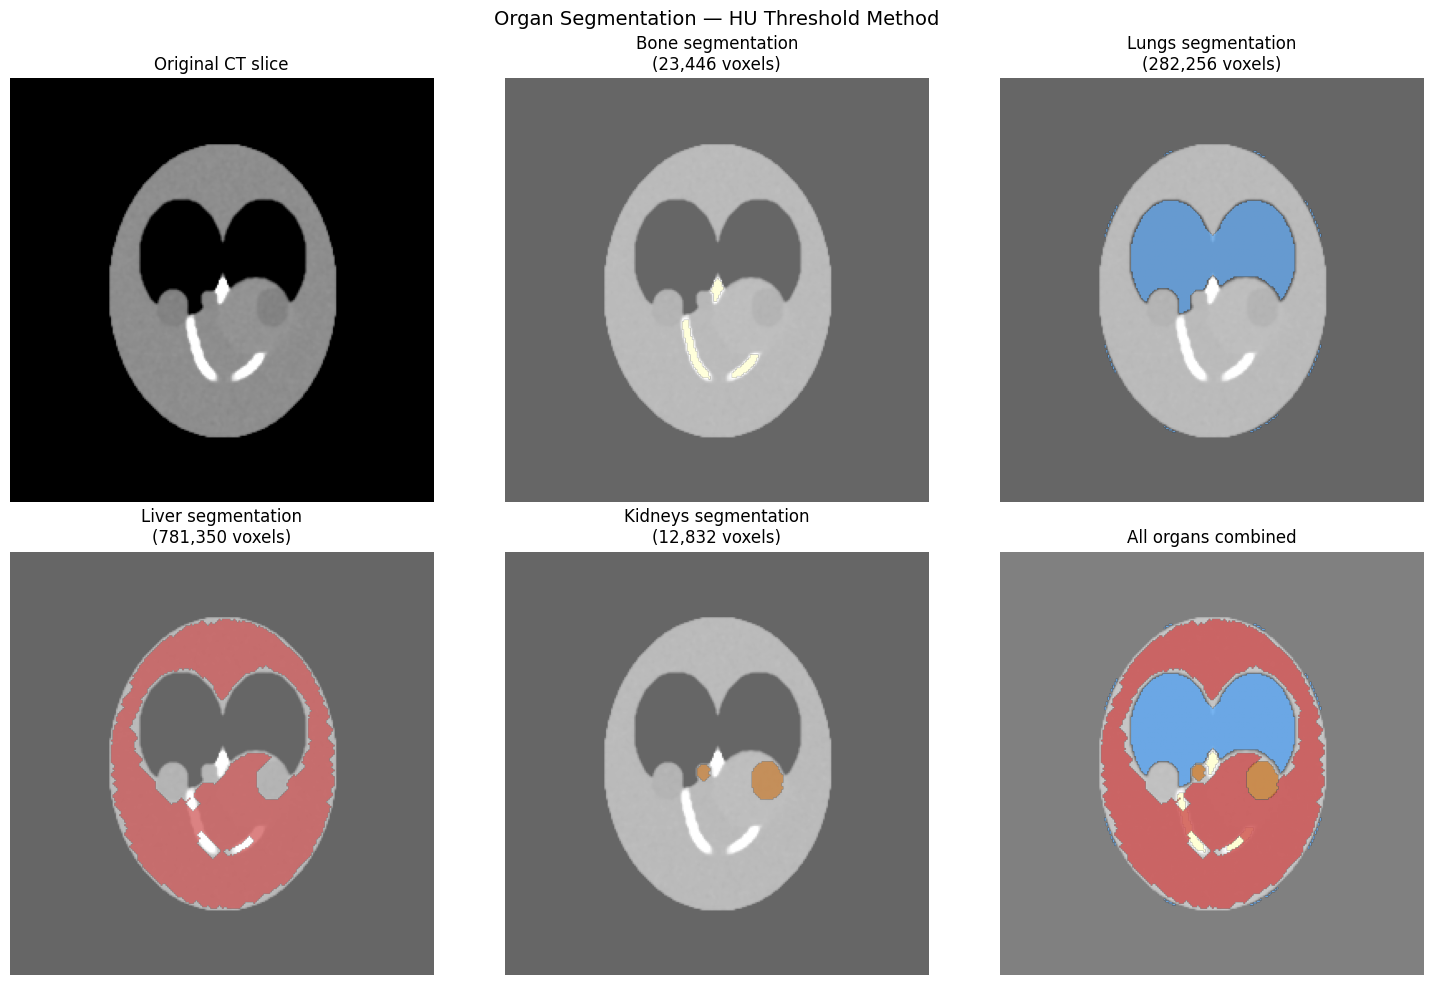

Saved to outputs/segmentation.png


In [3]:
mid_z = volume.shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# original CT
axes[0,0].imshow(volume[mid_z], cmap='gray', vmin=-200, vmax=250)
axes[0,0].set_title('Original CT slice')
axes[0,0].axis('off')

# individual organ masks
organ_colors = {
    'bone':    ('Bone',    [1.0, 1.0, 0.8]),
    'lungs':   ('Lungs',   [0.4, 0.7, 1.0]),
    'liver':   ('Liver',   [0.8, 0.3, 0.3]),
    'kidneys': ('Kidneys', [0.8, 0.5, 0.2]),
}

positions = [(0,1), (0,2), (1,0), (1,1)]
for (row,col), (organ, (label, color)) in zip(positions, organ_colors.items()):
    ax = axes[row, col]
    # show CT in background
    ax.imshow(volume[mid_z], cmap='gray', vmin=-200, vmax=250, alpha=0.6)
    # overlay mask in color
    mask_slice = masks[organ][mid_z].astype(float)
    colored = np.zeros((*mask_slice.shape, 4))
    colored[..., 0] = color[0] * mask_slice
    colored[..., 1] = color[1] * mask_slice
    colored[..., 2] = color[2] * mask_slice
    colored[..., 3] = mask_slice * 0.7
    ax.imshow(colored)
    ax.set_title(f'{label} segmentation\n({masks[organ].sum():,} voxels)')
    ax.axis('off')

# combined overlay
axes[1,2].imshow(volume[mid_z], cmap='gray', vmin=-200, vmax=250, alpha=0.5)
for organ, (label, color) in organ_colors.items():
    mask_slice = masks[organ][mid_z].astype(float)
    colored = np.zeros((*mask_slice.shape, 4))
    colored[..., 0] = color[0] * mask_slice
    colored[..., 1] = color[1] * mask_slice
    colored[..., 2] = color[2] * mask_slice
    colored[..., 3] = mask_slice * 0.8
    axes[1,2].imshow(colored)
axes[1,2].set_title('All organs combined')
axes[1,2].axis('off')

plt.suptitle('Organ Segmentation — HU Threshold Method', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/segmentation.png")